In [1]:
import os
import re
import random
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [17]:
# Path to images folder
data_dir = "./data/raw/autoPET/imagesTr"

# Find all CT (ending in _0000.nii.gz) and PET (ending in _0001.nii.gz)
ct_files = sorted([f for f in os.listdir(data_dir) if f.endswith("_0000.nii.gz")])
pet_files = sorted([f for f in os.listdir(data_dir) if f.endswith("_0001.nii.gz")])

print(f"Found {len(ct_files)} CT files and {len(pet_files)} PET files")



Found 1614 CT files and 1614 PET files



Loading pair:
fdg_0af7ffe12a_08-12-2005-NA-PET-CT Ganzkoerper  primaer mit KM-96698_0000.nii.gz
fdg_0af7ffe12a_08-12-2005-NA-PET-CT Ganzkoerper  primaer mit KM-96698_0001.nii.gz
CT shape: (400, 400, 304) range: (np.float64(-1292.346435546875), np.float64(3582.118408203125))
PET shape: (400, 400, 304) range: (np.float64(0.0), np.float64(74.66661071777344))


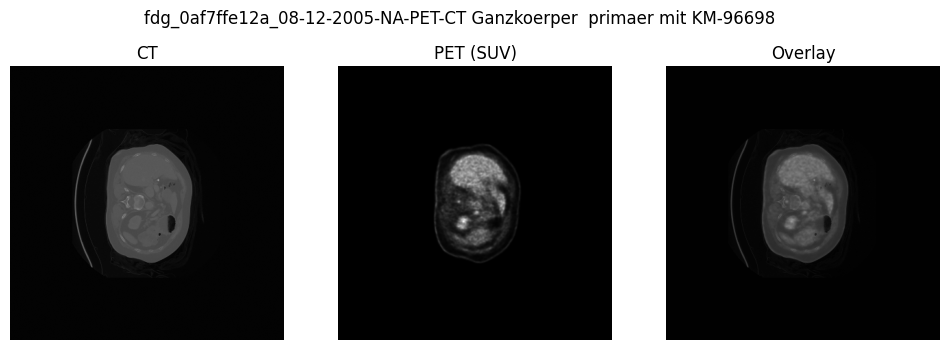


Loading pair:
fdg_0beb67c923_07-25-1999-NA-PET-CT Ganzkoerper  primaer mit KM-37911_0000.nii.gz
fdg_0beb67c923_07-25-1999-NA-PET-CT Ganzkoerper  primaer mit KM-37911_0001.nii.gz
CT shape: (400, 400, 326) range: (np.float64(-1432.0985107421875), np.float64(3234.91259765625))
PET shape: (400, 400, 326) range: (np.float64(0.0), np.float64(103.69011688232422))


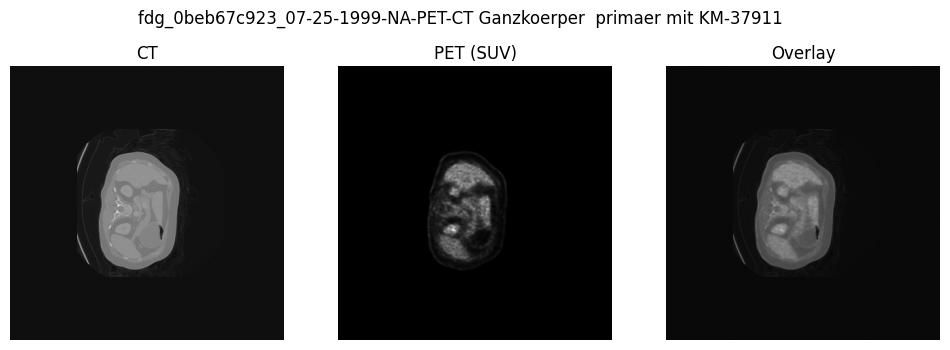


Loading pair:
fdg_0c13e4df10_10-11-2003-NA-PET-CT Ganzkoerper  primaer mit KM-89759_0000.nii.gz
fdg_0c13e4df10_10-11-2003-NA-PET-CT Ganzkoerper  primaer mit KM-89759_0001.nii.gz
CT shape: (400, 400, 326) range: (np.float64(-1469.2305908203125), np.float64(3354.453857421875))
PET shape: (400, 400, 326) range: (np.float64(0.0), np.float64(105.86614227294922))


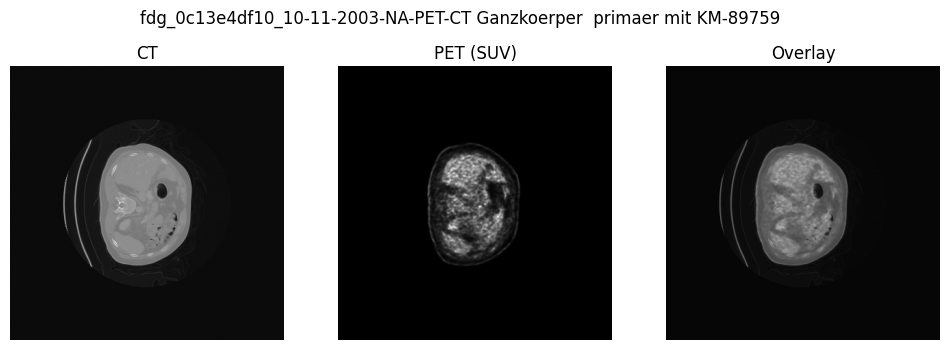

In [3]:
# Pair matching based on filename prefix
def find_pair(ct_file):
    prefix = ct_file.replace("_0000.nii.gz", "")
    pet = prefix + "_0001.nii.gz"
    if pet in pet_files:
        return os.path.join(data_dir, ct_file), os.path.join(data_dir, pet)
    return None, None

def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def visualize_pair(ct, pet, title):
    # Pick central axial slice
    z = ct.shape[2] // 2

    ct_slice = ct[:,:,z]
    pet_slice = pet[:,:,z]

    # normalize for display
    ct_norm = (ct_slice - np.min(ct_slice)) / (np.max(ct_slice) - np.min(ct_slice))
    pet_norm = (pet_slice - np.min(pet_slice)) / (np.max(pet_slice) - np.min(pet_slice))

    plt.figure(figsize=(12,4))
    plt.suptitle(title)

    # CT
    plt.subplot(1,3,1)
    plt.imshow(ct_norm, cmap="gray")
    plt.title("CT")
    plt.axis("off")

    # PET
    plt.subplot(1,3,2)
    plt.imshow(pet_norm, cmap="gray")
    plt.title("PET (SUV)")
    plt.axis("off")

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(ct_norm, cmap="gray")
    plt.imshow(pet_norm, cmap="gray", alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

for _ in range(3):  # show 3 random examples
    ct_file = random.choice(ct_files)
    ct_path, pet_path = find_pair(ct_file)
    if ct_path is None:
        continue

    print(f"\nLoading pair:")
    print(os.path.basename(ct_path))
    print(os.path.basename(pet_path))

    ct = load_nii(ct_path)
    pet = load_nii(pet_path)

    print("CT shape:", ct.shape, "range:", (ct.min(), ct.max()))
    print("PET shape:", pet.shape, "range:", (pet.min(), pet.max()))

    visualize_pair(ct, pet, title=os.path.basename(ct_path).replace("_0000.nii.gz",""))


In [20]:
from PIL._imaging import display

stats = []
shapes = []
# draw a sample from ctfiles
sample = np.random.choice(ct_files, 5)
for ct_file in tqdm(sample, desc="Processing CT/PET pairs"):
    prefix = ct_file.replace("_0000.nii.gz", "")
    pet_file = prefix + "_0001.nii.gz"

    ct_path = os.path.join(data_dir, ct_file)
    pet_path = os.path.join(data_dir, pet_file)

    if not os.path.exists(pet_path):
        print("⚠️ Missing PET for:", ct_file)
        continue

    ct = load_nii(ct_path)
    pet = load_nii(pet_path)

    shapes.append((ct.shape, pet.shape))

    stats.append({
        "prefix": prefix,
        "ct_min": np.min(ct), "ct_max": np.max(ct), "ct_mean": np.mean(ct), "ct_std": np.std(ct),
        "pet_min": np.min(pet), "pet_max": np.max(pet), "pet_mean": np.mean(pet), "pet_std": np.std(pet),
    })

stats_df = pd.DataFrame(stats)
stats_df

Processing CT/PET pairs: 100%|██████████| 5/5 [00:12<00:00,  2.52s/it]


,prefix,ct_min,ct_max,ct_mean,ct_std,pet_min,pet_max,pet_mean,pet_std
0,fdg_c395306306_08-24-2002-NA-PET-CT Ganzkoerpe...,-1310.093262,3216.895508,-913.387021,306.941588,0.0,41.317699,0.096563,0.582690
1,psma_4da96443cf212c5f_2020-08-31,-1648.338013,3564.378662,-889.291383,339.656273,0.0,48.185688,0.152713,1.005529
2,psma_7bd096b4afea75d8_2017-02-27,-3860.557129,3619.236084,-1067.138434,761.821444,0.0,51.786572,0.132343,1.098159
3,fdg_a21200dcba_03-10-2005-NA-PET-CT Ganzkoerpe...,-1317.828613,3011.117920,-924.360473,290.861602,0.0,61.819134,0.082039,0.506995
4,fdg_4cb875dc0b_01-13-2005-NA-PET-CT Ganzkoerpe...,-1487.287964,3507.483887,-954.470396,241.240168,0.0,34.622280,0.053699,0.403132


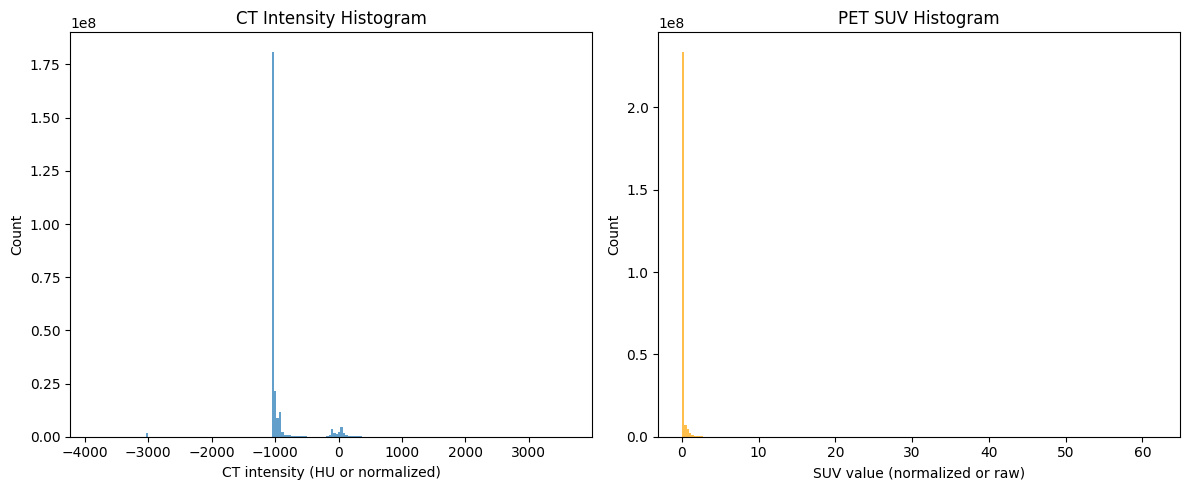

In [21]:
# Sample a few for histograms to avoid memory explosion
sampled = stats_df.sample(min(5, len(stats_df)))

ct_vals = []
pet_vals = []

for _, row in sampled.iterrows():
    ct = load_nii(os.path.join(data_dir, row["prefix"] + "_0000.nii.gz"))
    pet = load_nii(os.path.join(data_dir, row["prefix"] + "_0001.nii.gz"))

    ct_vals.append(ct.flatten())
    pet_vals.append(pet.flatten())

ct_vals = np.concatenate(ct_vals)
pet_vals = np.concatenate(pet_vals)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(ct_vals, bins=200, alpha=0.7)
plt.title("CT Intensity Histogram")
plt.xlabel("CT intensity (HU or normalized)")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(pet_vals, bins=200, alpha=0.7, color="orange")
plt.title("PET SUV Histogram")
plt.xlabel("SUV value (normalized or raw)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()
